### Generating Depth Maps from RGB Images

In [2]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

from depth_anything_v2.dpt import DepthAnythingV2

%matplotlib inline

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

xFormers not available
xFormers not available
xFormers not available


PyTorch version: 2.5.1+cu121
CUDA available: True


<br>

#### Section 2: Load Depth Anything V2 Model

Available encoder variants (accuracy vs. speed tradeoff):

| Encoder | Parameters | Speed | Accuracy | Checkpoint File |
|---------|------------|-------|----------|-----------------|
| `vits` | ~25M | Fastest | Lower | `depth_anything_v2_vits.pth` |
| `vitb` | ~97M | Fast | Medium | `depth_anything_v2_vitb.pth` |
| `vitl` | ~335M | Moderate | High | `depth_anything_v2_vitl.pth` |
| `vitg` | ~1.0B | Slowest | Highest | `depth_anything_v2_vitg.pth` |

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Model configurations
configs = {
    'vits': {'encoder': 'vits', 'features': 64, 'out_channels': [48, 96, 192, 384]},
    'vitb': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
    'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]},
    'vitg': {'encoder': 'vitg', 'features': 384, 'out_channels': [1536, 1536, 1536, 1536]}
}

encoder="vitl"
print(encoder)

# Load model
model = DepthAnythingV2(encoder)
model.load_state_dict(torch.load(f'checkpoints/depth_anything_v2_{encoder}.pth', map_location='cuda'))

# if you dont have gpu supported
model = model.to(device).eval()

vitl


C:\Users\sirom\AppData\Local\Temp\ipykernel_6820\2806638833.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'checkpoints/depth_anythin

: 

<br>

#### Section 3: Load and Prepare Input Image

Configure the image path and load the RGB image for depth estimation.

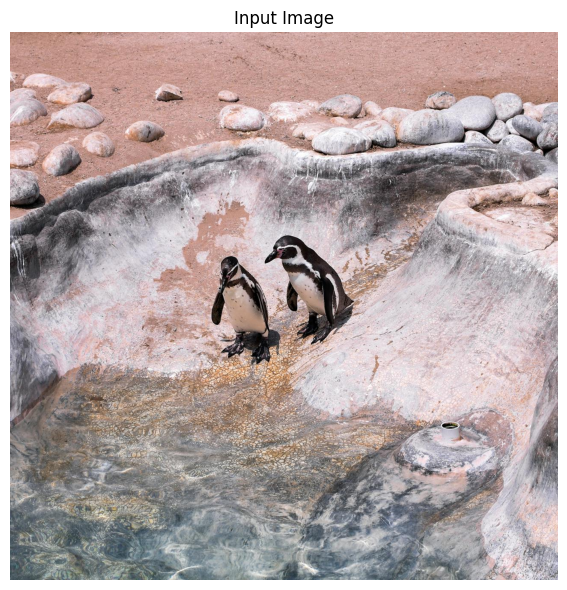

In [7]:
IMAGE_PATH = r"assets/penguin.jpg"# Modify this path to your image

# Load image
image = cv2.imread(IMAGE_PATH)

# Display original image
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Input Image')
plt.axis('off')
plt.tight_layout()
plt.show()

#### Section 4: Generate Depth Map

Run depth estimation inference using Depth Anything V2 to create a depth map.

In [8]:
# Compute depth map
depth_map = model.infer_image(image)

print(f"  Shape: {depth_map.shape}")
print(f"  Data type: {depth_map.dtype}")
print(f"  Value range: [{depth_map.min():.4f}, {depth_map.max():.4f}]")
print(f"  Mean value: {depth_map.mean():.4f}")
print(f"  Std deviation: {depth_map.std():.4f}")

  Shape: (1280, 1280)
  Data type: float32
  Value range: [11.3324, 510.0683]
  Mean value: 234.4335
  Std deviation: 110.9067


#### Section 5: Visualize Depth Map

Create a side-by-side visualization of the original image and the generated depth map.

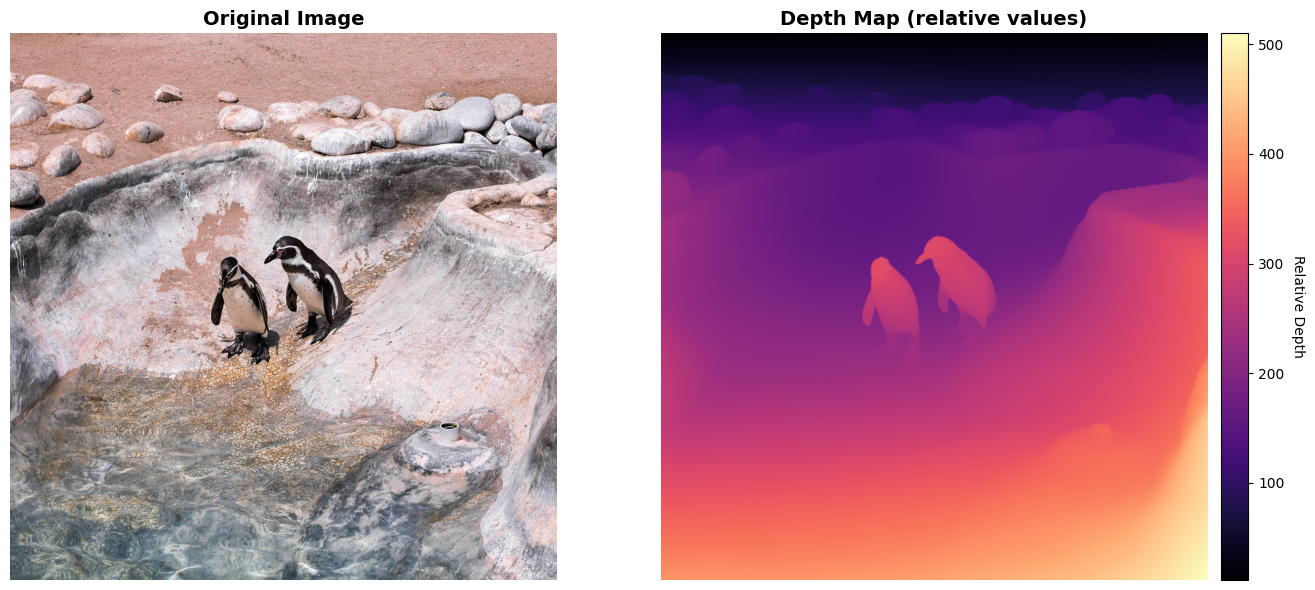

In [11]:
# Create side-by-side visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left panel: Original image
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Image', fontsize=14, weight='bold')
axes[0].axis('off')

# Right panel: Depth map
im = axes[1].imshow(depth_map, cmap='magma')
axes[1].set_title('Depth Map (relative values)', fontsize=14, weight='bold')
axes[1].axis('off')

# Add colorbar with tighter spacing
cbar = plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.02)
cbar.set_label('Relative Depth', rotation=270, labelpad=15)

# Reduce spacing between subplots
plt.subplots_adjust(wspace=0.01)

plt.tight_layout()
plt.show()

(np.float64(-0.5), np.float64(1279.5), np.float64(1279.5), np.float64(-0.5))

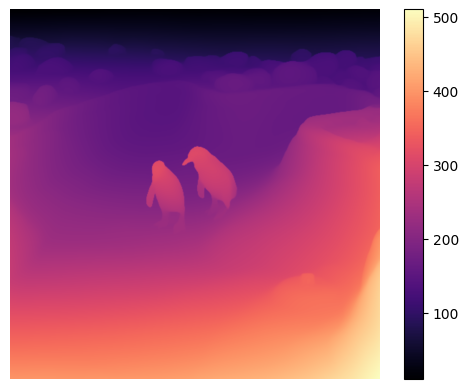

In [12]:
plt.imshow(depth_map, cmap='magma')
plt.colorbar()
plt.axis('off')

In [13]:
type(depth_map)

numpy.ndarray

In [14]:
np.shape(depth_map)

(1280, 1280)

In [15]:
print(depth_map[0][0])
print(depth_map[600][600])

11.388075
181.72585
